#  Evolutionary Multiple-objective Optimization (part for 4.0)

- This script is for those who want to improve their final grade from 3.0 to 4.0. 
- Your task is to implement any one evolutionary algorithm for multiple-objective optimization introduced during the lecture (NSGA-II/NSGA-III/MOEA/D; except for NSGA).
- Note that it has to be your implementation (using external libraries is forbidden; EXCEPTION: you can use the JECDM framework: https://jecdm.cs.put.poznan.pl -- but it is a relatively complex software, and much effort must be spent to understand how to use it).
- The problem to be solved is the portfolio optimization tackled during lab 1.
- You can use the same data and price predictions as you made for lab 1 (Bundle1.zip) or update them accordingly to the next stage if you participate in the portfolio game (it is up to you).
- Apart from the two-objective scenario, tackle also a three-objective one. As for the third objective, think about some reasonable risk-measure. E.g., you can maximize the number of non-zero weights, which should refer to minimizing risk by diversifying investments.
- Perform experimental evaluation of your implementation. You can use, e.g., the IDG or the HV metric to quantify the quality of populations constructed by the method.
- The experimental evaluation should be "reasonably extensive." E.g., run your method multiple times and average the results, show average convergence plots, do the sensitivity analysis (just four combinations of population size/generations will be enough), and depict some final populations. Also, compare the populations (only for 2D scenarios) with those generated by the ECM or WSM algorithm. Note that ECM and WSM already generate Pareto optimal solutions, so these can be considered good benchmarks for comparison.
- You can report your results here, i.e., in the jupyter notebook. You do not need to prepare any pdf report, etc. 

This notebook is the implementation of the MOAE/D genetic algorithm for multi-objective optimization. Additionally, a comprehensive comparison of the algorithm's convergence, and 

In [1]:
from utils.MOO_utilities import *
from pymoo.indicators.hv import HV

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

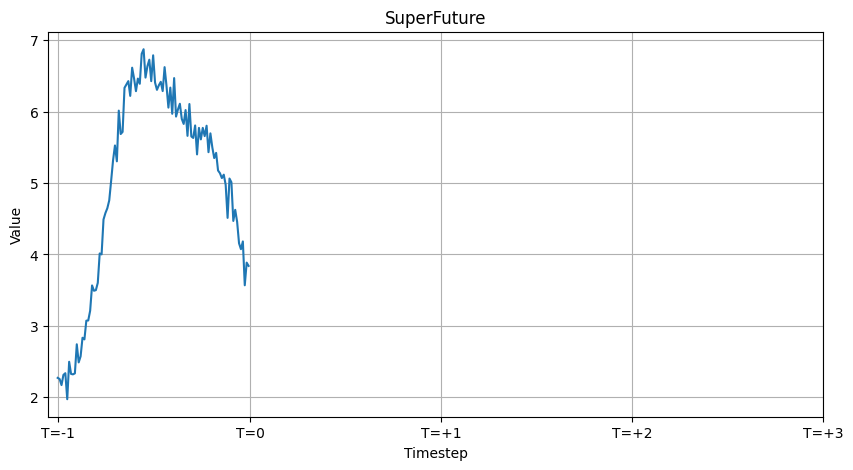

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

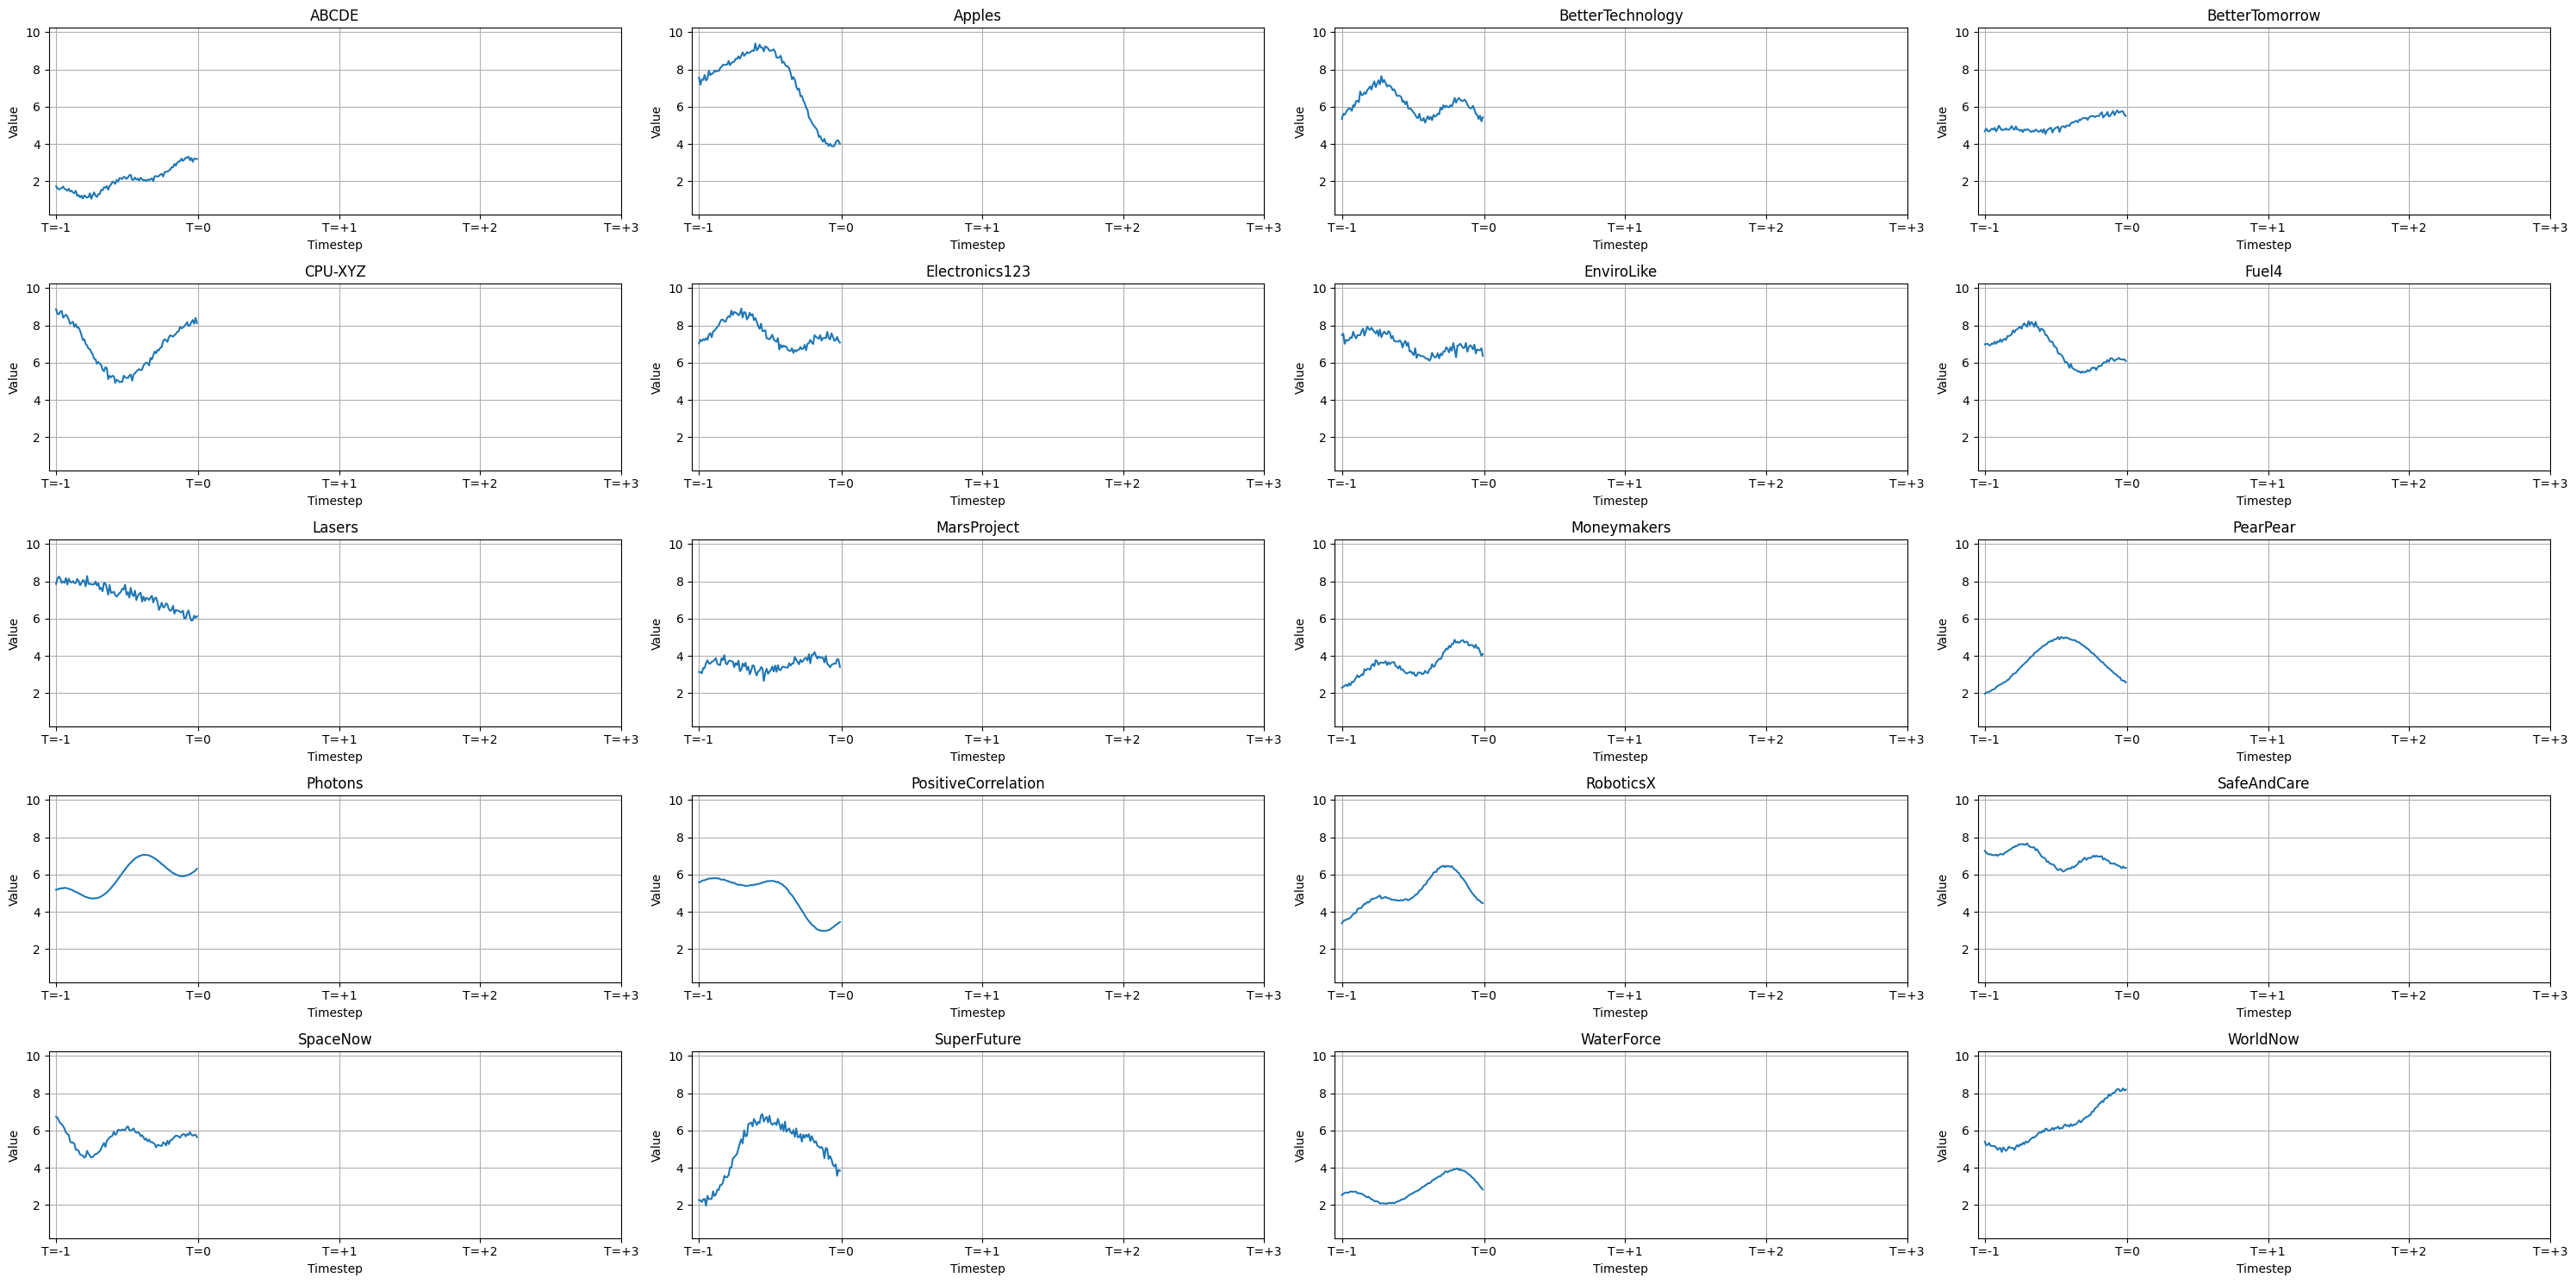

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

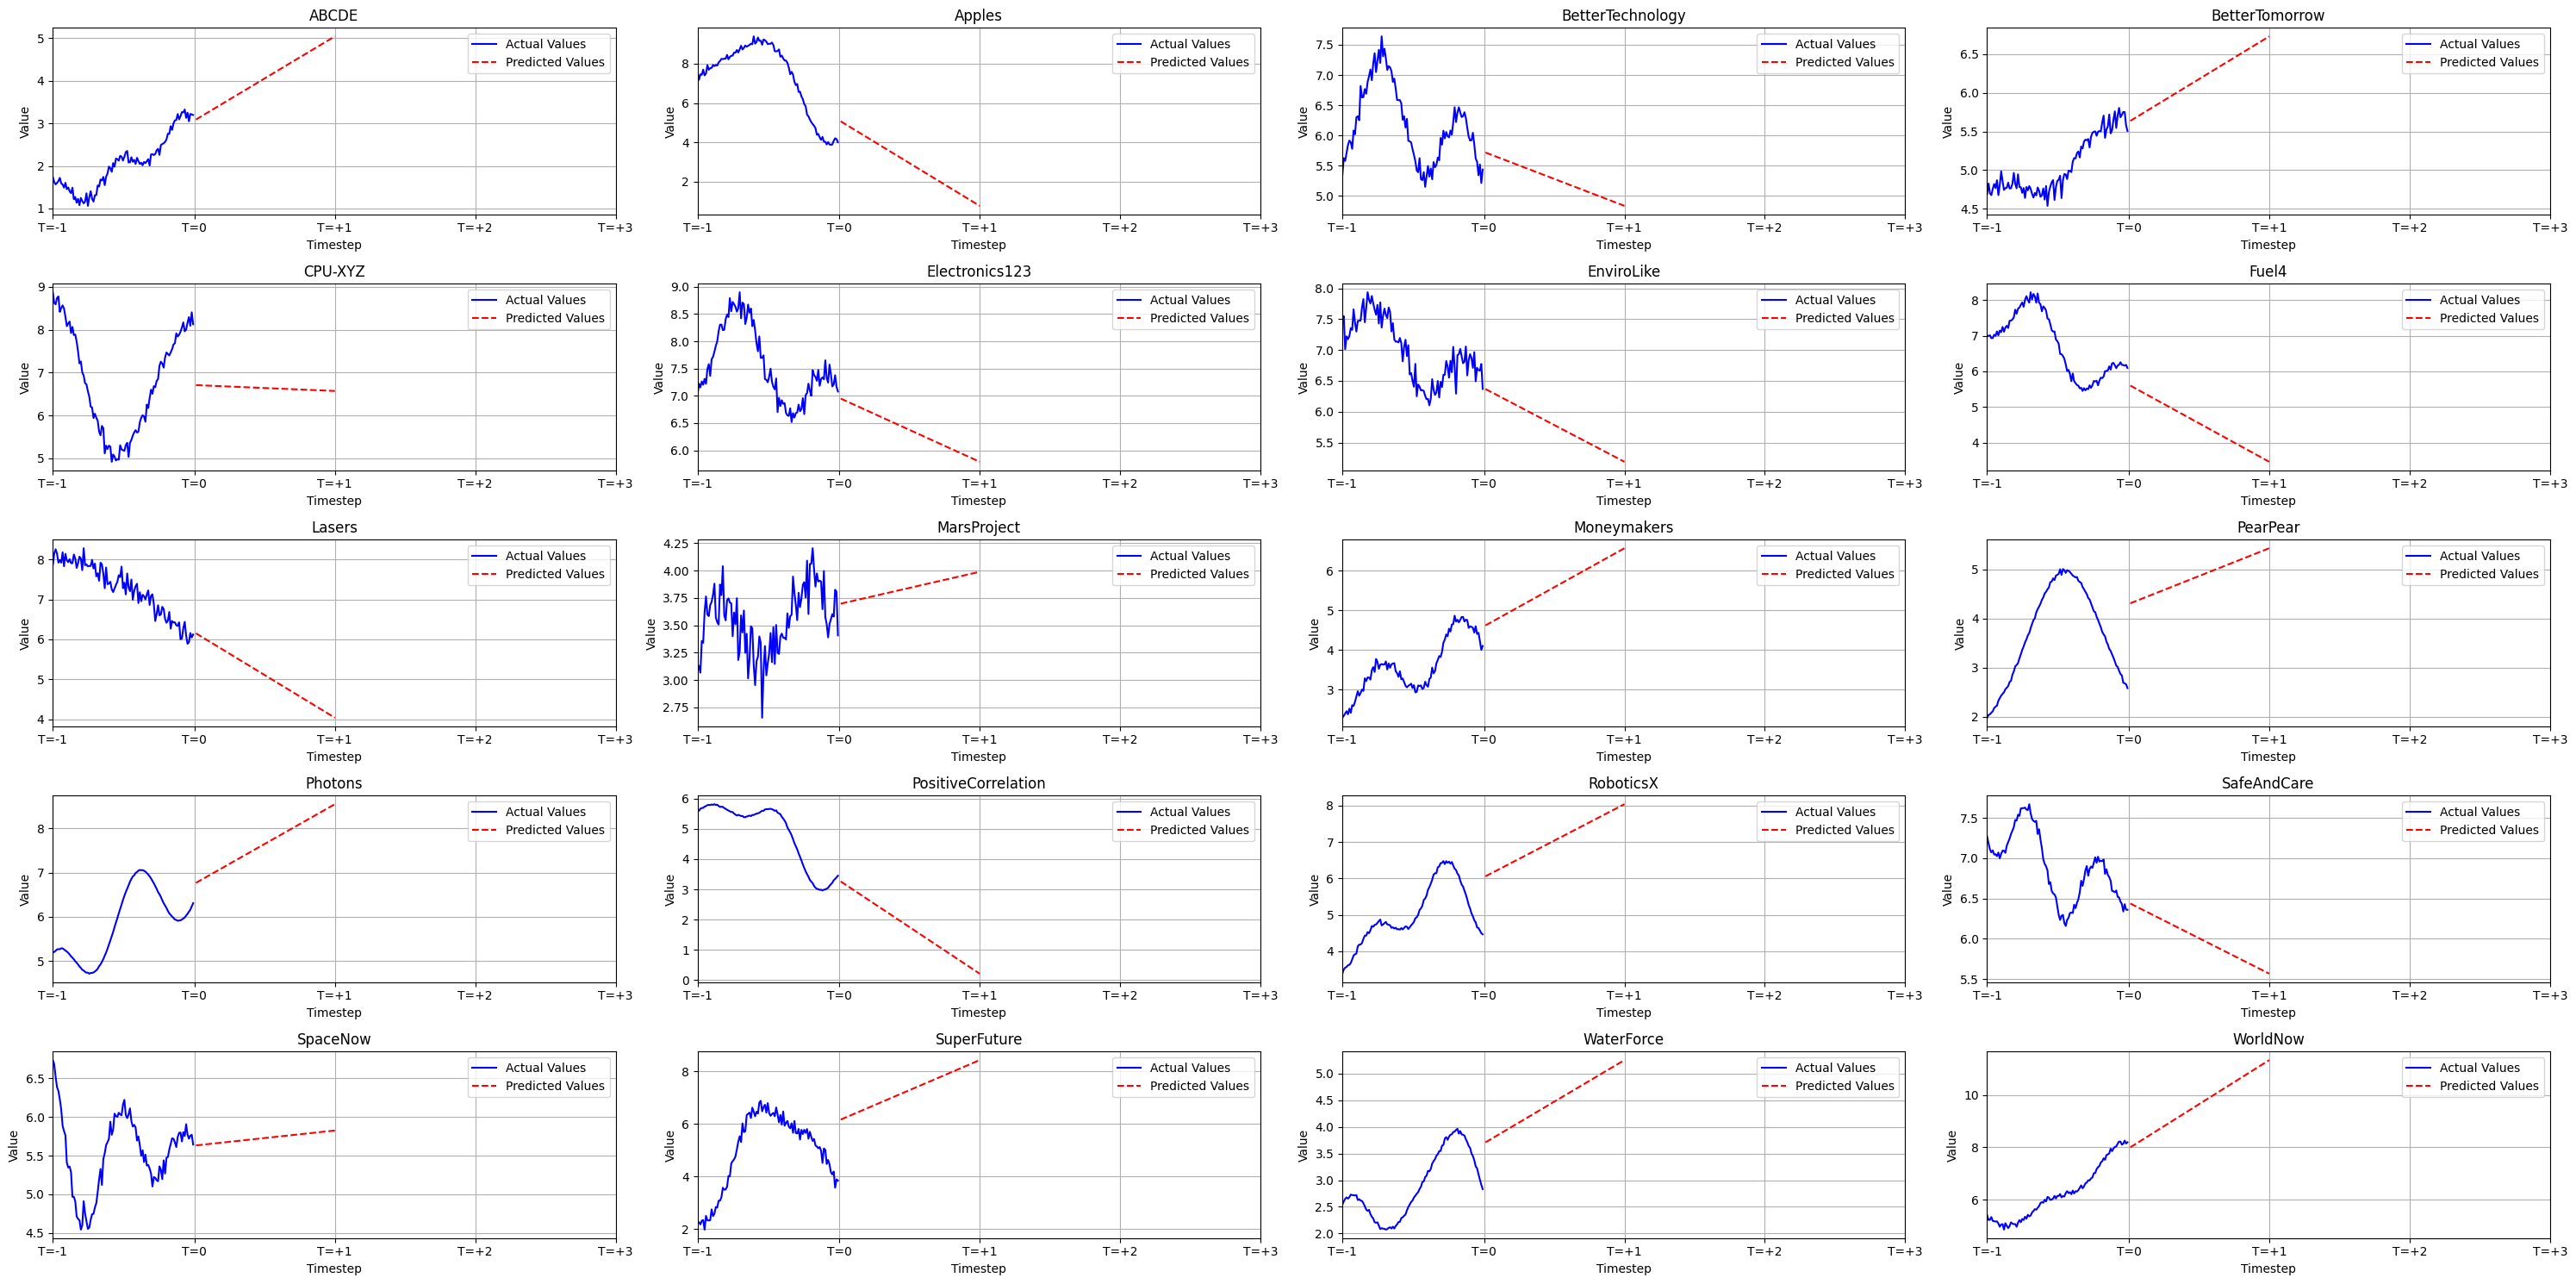

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

In [6]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [7]:
def transform_solution(solution):
    new_sol = []
    for example in solution:
        temp = []
        temp.append(example[0])
        temp.append(example[1])
        for val in example[-1]:
            temp.append(val)
        new_sol.append(temp.copy())
    return np.array(new_sol, dtype=np.float32)

def calculate_3d_hypervolume(population: np.ndarray, ref_point: np.ndarray) -> float:
    hv_value = HV(ref_point = ref_point)(population)
    return hv_value

def find_non_dominated(F):
    M = np.zeros((F.shape[0], F.shape[0]))
    for i in range(F.shape[0]):
        for j in range(F.shape[0]):
            if np.all(F[i] <= F[j]) and not np.all(F[i] == F[j]):
                M[i, j] = 1
            elif np.all(F[j] <= F[i]) and not np.all(F[j] == F[i]):
                M[i, j] = -1
    I = np.where(np.all(M >= 0, axis=1))[0]
    return I

def calculate_2d_hyperarea(solutions, reference_point):
    solutions = solutions.astype(float)
    reference_point = reference_point.astype(float)
    non_dom = find_non_dominated(solutions)
    F = np.copy(solutions[non_dom, :])

    if F.shape[0] == 0:
        return 0.0

    F = F - reference_point
    F = np.array(sorted(F.tolist(), key=lambda x: (x[1], x[0])))

    hyperarea = 0.0
    h = -F[0][0]
    for i in range(1, len(F)):
        hyperarea += h * (F[i - 1][1] - F[i][1])
        h = max(h, -F[i][0])
    hyperarea += h * F[-1][1]
    return -1*hyperarea

def find_non_dominated(F, _F=None):
    M = np.zeros((F.shape[0],F.shape[0]))
    for i in range(F.shape[0]):
      for j in range(F.shape[0]):
        if np.all(F[i]<=F[j]) and not np.all(F[i]==F[j]):
          M[i,j] = 1
        elif np.all(F[j]<=F[i]) and not np.all(F[j]==F[i]):
          M[i,j] = -1
    I = np.where(np.all(M >= 0, axis=1))[0]
    return I

class GeneticSolver(Solver):
    def __init__(self, data, predicted_vals, risks, population_size, mutation_probability, weight_size=20, num_dimensions=2):
        super().__init__(data, predicted_vals, risks)
        self.population_size = population_size  
        self.weight_size = weight_size
        self.log_history = False
        self.num_dimensions = num_dimensions
        self.mutation_prob = mutation_probability

    def enable_loging(self):
        self.log_history = True
    
    def disable_loging(self):
        self.log_history = False

    def normalize(self, population):
        return population / population.sum(axis=1, keepdims=True)
    
    def normalize_population_values(self, population, num_dims=2):
        values = []
        for weights in population:
            if num_dims == 3:
                potential_gain = self.maxf1 - (weights.T @ self.expected_returns)
                risk = weights.T @ self.risks @ weights
                potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
                num_zero_weights = np.sum(weights < 0.01)/self.weight_size
                risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
                temp = [potential_gain, risk, num_zero_weights]
            else:
                potential_gain = self.maxf1 - (weights.T @ self.expected_returns)
                risk = weights.T @ self.risks @ weights
                potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
                risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
                temp = [potential_gain, risk]
            values.append(temp.copy())
        return np.array(values, dtype=np.float32)

    def generate_population(self):
        population = np.array([[random.random() for i in range(self.weight_size)].copy() for i in range(self.population_size)], dtype=np.float32)
        population = self.normalize(population)
        if self.log_history:
            self.population_history = []
            self.population_history.append(population.copy()) 
        return population
    
    def initialize_chebyshev(self):
        if self.num_dimensions <= 1:
            print("At least two dimensions must be present")
            raise ValueError
        elif self.num_dimensions == 2:
            samples_dim_1 = np.linspace(0, 1, self.population_size)
            samples_dim_2 = 1 - samples_dim_1
            weights = []
            for i in range(len(samples_dim_1)):
                weights.append([samples_dim_1[i], samples_dim_2[i]])
            weights = np.array(weights, dtype=np.float32)
        else:
            weights = np.random.dirichlet(np.ones(self.num_dimensions), self.population_size).astype(np.float32)
        return weights
    
    def crossover(self, chebyshev_weights, neighborhoods, weight_to_individual_map):
        offsprings = []
        for weight in chebyshev_weights:
            neighboring_weights = neighborhoods[tuple(weight)].copy()
            random.shuffle(neighboring_weights)
            weight_parent_1, weight_parent_2 = neighboring_weights[:2]
            parent_1, parent_2 = weight_to_individual_map[weight_parent_1], weight_to_individual_map[weight_parent_2]
            crossing_point = random.randint(0, len(parent_1)-1)
            result = np.concatenate((parent_1[:crossing_point], parent_2[crossing_point:]))
            offsprings.append(result)
        offsprings = np.array(offsprings, dtype=np.float32)
        return offsprings
    
    def mutate(self, population):
        new_population = []
        for individual in population:
            if random.random() < self.mutation_prob:
                idx = random.randint(0, len(individual) - 1)
                individual[idx] = random.random()
            new_population.append(individual)
        new_population = np.array(new_population, dtype=np.float32)
        return new_population
    
    def find_neighborhoods(self, chebyshev_weights, neighborhood_size):
        distances = np.abs(chebyshev_weights[:, None] - chebyshev_weights).sum(axis=-1)
        neighbors_dict = {}
        for i, w in enumerate(chebyshev_weights):
            sorted_indices = np.argsort(distances[i])
            closest_indices = sorted_indices[1:neighborhood_size+1]
            neighbors_dict[tuple(w)] = [tuple(chebyshev_weights[j]) for j in closest_indices]
        return neighbors_dict
    
    def assign_chebyshev_weights(self, population, chebyshev_weights):
        np.random.shuffle(chebyshev_weights)
        weight_to_individual_map = {tuple(chebyshev_weights[i]): population[i] for i in range(self.population_size)}
        return weight_to_individual_map
    
    def calculate_chebyshev_distance(self, weight, investment_vector):
        potential_gain = self.maxf1 - (investment_vector.T @ self.expected_returns)
        #risk = np.sqrt(investment_vector.T @ self.risks @ investment_vector)
        risk = investment_vector.T @ self.risks @ investment_vector
        potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
        risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
        return max(weight[0]*potential_gain, weight[1]*risk)
    
    def calculate_chebyshev_3d_distance(self, weight, investment_vector):
        potential_gain = self.maxf1 - (investment_vector.T @ self.expected_returns)
        #risk = np.sqrt(investment_vector.T @ self.risks @ investment_vector)
        risk = investment_vector.T @ self.risks @ investment_vector
        potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
        num_zero_weights = np.sum(investment_vector < 0.01)/self.weight_size
        risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
        return max(weight[0]*potential_gain, weight[1]*risk, weight[2] * num_zero_weights)
    
    def perform_selection(self, population, offsprings, chebyshev_weights, weight_to_individual_map):
        #Spaghetti code, but I do not care as long as it works
        complete_pool = np.concatenate((population, offsprings))
        next_generation = []
        for weight in chebyshev_weights:
            current_best = None
            if self.num_dimensions == 3:
                chebyshev_distance_current = self.calculate_chebyshev_3d_distance(weight, weight_to_individual_map[tuple(weight)])
            else:
                chebyshev_distance_current = self.calculate_chebyshev_distance(weight, weight_to_individual_map[tuple(weight)])
            for individual in complete_pool:
                if self.num_dimensions == 3:
                    chebyshev_distance_new = self.calculate_chebyshev_3d_distance(weight, individual)
                else:
                    chebyshev_distance_new = self.calculate_chebyshev_distance(weight, individual)
                if chebyshev_distance_new <= chebyshev_distance_current:
                    current_best = individual
            next_generation.append(current_best)
            weight_to_individual_map[tuple(weight)] = current_best
        return np.array(next_generation, dtype=np.float32), weight_to_individual_map

    def genetic_optimize(self, generations=10, neighborhood_size=2):
        chebyshev_weights = self.initialize_chebyshev()
        neighborhoods = self.find_neighborhoods(chebyshev_weights, neighborhood_size)
        population = self.generate_population()
        population = self.normalize(population)
        weight_to_individual_map = self.assign_chebyshev_weights(population, chebyshev_weights)
        for generation in range(generations):
            offsprings = self.crossover(chebyshev_weights, neighborhoods, weight_to_individual_map)
            offsprings = self.normalize(offsprings)
            offsprings = self.mutate(offsprings)
            offsprings = self.normalize(offsprings)
            population, weight_to_individual_map = self.perform_selection(population, offsprings, chebyshev_weights, weight_to_individual_map)
            if self.log_history:
                self.population_history.append(self.normalize(population.copy()))
        return population
    
    def get_solutions_from_population(self, population):
        solutions = []
        for individual in population:
            solution = []
            potential_gain = individual.T @ self.expected_returns
            #risk = np.sqrt(individual.T @ self.risks @ individual)
            risk = individual.T @ self.risks @ individual
            solution.append(potential_gain)
            solution.append(risk)
            solution.append(individual.copy())
            solutions.append(solution.copy())
        return solutions
    
    def get_solutions_from_population_3D(self, population):
        solutions = []
        for individual in population:
            solution = []
            potential_gain = individual.T @ self.expected_returns
            #risk = np.sqrt(individual.T @ self.risks @ individual)
            risk = individual.T @ self.risks @ individual
            num_zero_weights = np.sum(individual < 0.01)/self.weight_size
            solution.append(potential_gain)
            solution.append(risk)
            solution.append(num_zero_weights)
            solution.append(individual.copy())
            solutions.append(solution.copy())
        return solutions

    def plot_sampled_3D(self, n=20, step=0.2, color=True):
        random_points = []        
        results = self._generate_uniform_weights(n, step)
        
        for res in results:  
            sol_weights = np.array(res)
            f1, f2 = self.get_objective_values(sol_weights)  # Assuming f3 exists
            f3 = np.sum(sol_weights < 0.01)/self.weight_size
            random_points.append((f1, f2, f3))
        
        if color:
            plt.figure(figsize=(10, 9))
            scatter = plt.scatter(
                [x[0] for x in random_points], 
                [x[1] for x in random_points], 
                c=[x[2] for x in random_points],  # Color by f3
                cmap='viridis', 
                edgecolors='k'
            )
            plt.colorbar(scatter, label='Non-Zero Weights')
            plt.xlabel("Expected Return")
            plt.ylabel("Risk")
            plt.title("Sampled Decision Variables")
            plt.grid(True)
            plt.show()
        else:
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            
            axs[0].scatter([x[0] for x in random_points], [x[1] for x in random_points])
            axs[0].set_xlabel("Expected Gain")
            axs[0].set_ylabel("Risk")
            axs[0].set_title("Expected Gain vs Risk")
            
            axs[1].scatter([x[1] for x in random_points], [x[2] for x in random_points])
            axs[1].set_xlabel("Risk")
            axs[1].set_ylabel("Non-Zero Weights")
            axs[1].set_title("Risk vs Non-Zero Weights")
            
            axs[2].scatter([x[0] for x in random_points], [x[2] for x in random_points])
            axs[2].set_xlabel("Expected Gain")
            axs[2].set_ylabel("Non-Zero Weights")
            axs[2].set_title("Expected Gain vs Non-Zero Weights")
            
            for ax in axs:
                ax.grid(True)
            
            plt.tight_layout()
            plt.show()

    def plot_front_3D(self, solutions, n=20, step=0.2, color=True):
        random_points = []        
        results = self._generate_uniform_weights(n, step)
        
        for res in results:  
            sol_weights = np.array(res)
            f1, f2 = self.get_objective_values(sol_weights)  # Assuming f3 exists
            f3 = np.sum(sol_weights < 0.01)/self.weight_size
            random_points.append((f1, f2, f3))
        
        if color:
            plt.figure(figsize=(10, 9))
            scatter = plt.scatter(
                [x[0] for x in random_points], 
                [x[1] for x in random_points], 
                c=[x[2] for x in random_points],  # Color by f3
                cmap='viridis', 
                edgecolors='k',
                alpha=0.3
            )
            plt.colorbar(scatter, label='Non-Zero Weights')
            
            solution_colors = [x[2] for x in solutions]  # Color solutions by their f3 values
            sol_scatter = plt.scatter(
                [x[0] for x in solutions], 
                [x[1] for x in solutions], 
                c=solution_colors, 
                cmap='coolwarm',  # Different gradient
                edgecolors='black',
                linewidths=1.5,
                label='Front Solutions'
            )
            plt.colorbar(sol_scatter, label='Solution Non-Zero Weights')
            
            plt.xlabel("Expected Return")
            plt.ylabel("Risk")
            plt.title("Sampled Decision Variables")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            
            axs[0].scatter([x[0] for x in random_points], [x[1] for x in random_points], alpha=0.8)
            axs[0].scatter([x[0] for x in solutions], [x[1] for x in solutions], color="red", linewidths=2)
            axs[0].set_xlabel("Expected Gain")
            axs[0].set_ylabel("Risk")
            axs[0].set_title("Expected Gain vs Risk")
            
            axs[1].scatter([x[1] for x in random_points], [x[2] for x in random_points], alpha=0.8)
            axs[1].scatter([x[1] for x in solutions], [x[2] for x in solutions], color="red", linewidths=2)
            axs[1].set_xlabel("Risk")
            axs[1].set_ylabel("Non-Zero Weights")
            axs[1].set_title("Risk vs Non-Zero Weights")
            
            axs[2].scatter([x[0] for x in random_points], [x[2] for x in random_points], alpha=0.8)
            axs[2].scatter([x[0] for x in solutions], [x[2] for x in solutions], color="red", linewidths=2)
            axs[2].set_xlabel("Expected Gain")
            axs[2].set_ylabel("Non-Zero Weights")
            axs[2].set_title("Expected Gain vs Non-Zero Weights")
            
            for ax in axs:
                ax.grid(True)
            
            plt.tight_layout()
            plt.show()

class GeneticExperimentRunner():
    def get_hypervolume_vs_population_size_vs_generations(self, pop_sizes, generations, data, predictions, risks):
        results = []
        for num_dims in [2, 3]:
            for pop_size in pop_sizes:
                for generation in generations:
                    GS = GeneticSolver(data, predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=num_dims)
                    population = GS.genetic_optimize(generations=generation, neighborhood_size=5)
                    if num_dims == 2:
                        ref_point = np.array([1.1, 1.1], dtype=np.float32)
                    else:
                        ref_point = np.array([1.1, 1.1, 1.1], dtype=np.float32)
                    population_values = GS.normalize_population_values(population, num_dims=num_dims)
                    if num_dims == 2:
                        hv_value = calculate_2d_hyperarea(population_values, ref_point)
                    else:
                        hv_value = calculate_3d_hypervolume(population_values, ref_point)
                    results.append([num_dims, pop_size, generation, hv_value])
        self.results = results

    def plot_hypervolume_vs_population_size_vs_generations(self):
        results = np.array(self.results)
        
        sns.set_style("whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(18, 10))
        
        for num_dims, ax in zip([2, 3], axes):
            subset = results[results[:, 0] == num_dims]
            
            for generation in np.unique(subset[:, 2]):
                filtered = subset[subset[:, 2] == generation]
                ax.plot(
                    filtered[:, 1],
                    filtered[:, 3],
                    marker='o',
                    linestyle='-',
                    label=f"Generations: {int(generation)}"
                )
            
            ax.set_title(f"Hypervolume vs Population Size (Dimensions: {num_dims})")
            ax.set_xlabel("Population Size")
            ax.set_ylabel("Hypervolume" if num_dims == 3 else "Hyperarea")
            ax.legend()
        
        plt.tight_layout()
        plt.show()

    def get_genetic_vs_classic(self, data, predictions, risks, num_retries=10):
        solver = Solver(data, predictions, risks)
        GS = GeneticSolver(data, predictions, risks, population_size=None, mutation_probability=0.8, weight_size=20, num_dimensions=2)
        self.wsm_solutions_step_001 = transform_solution(solver.solve_wsm(step = 0.01))
        self.wsm_solutions_step_025 = transform_solution(solver.solve_wsm(step = 0.05))
        self.wsm_solutions_step_010 = transform_solution(solver.solve_wsm(step = 0.1))
        self.ecm_solutions_100 = transform_solution(solver.solve_ecm(num_thresholds=101))
        self.ecm_solutions_20 = transform_solution(solver.solve_ecm(num_thresholds=21))
        self.ecm_solutions_10 = transform_solution(solver.solve_ecm(num_thresholds=11))
        
        self.wsm_solutions_step_001_hv = GS.normalize_population_values(self.wsm_solutions_step_001[:, 2: ], num_dims = 2)
        self.wsm_solutions_step_025_hv = GS.normalize_population_values(self.wsm_solutions_step_025[:, 2: ], num_dims = 2)
        self.wsm_solutions_step_010_hv = GS.normalize_population_values(self.wsm_solutions_step_010[:, 2: ], num_dims = 2)
        self.ecm_solutions_100_hv = GS.normalize_population_values(self.ecm_solutions_100[:, 2: ], num_dims = 2)
        self.ecm_solutions_20_hv = GS.normalize_population_values(self.ecm_solutions_20[:, 2: ], num_dims = 2)
        self.ecm_solutions_10_hv = GS.normalize_population_values(self.ecm_solutions_10[:, 2: ], num_dims = 2)
        results = []
        front = []
        for retry in range(num_retries):
            for pop_size in [10, 20, 100]:
                GS = GeneticSolver(data, predictions, risks, population_size=pop_size, mutation_probability=0.8, weight_size=20, num_dimensions=2)
                GS.enable_loging()
                GS.genetic_optimize(generations=100, neighborhood_size=5)
                population_history = GS.population_history
                for pop_index, population in enumerate(population_history):
                    ref_point = np.array([1.1, 1.1], dtype=np.float32)
                    population_values = GS.normalize_population_values(population, num_dims=2)
                    hv_value = calculate_2d_hyperarea(population_values, ref_point)
                    results.append([pop_size, pop_index, retry, hv_value])
        self.results = results

    def plot_genetic_vs_classic(self):
        results_df = pd.DataFrame(self.results, columns=['pop_size', 'generation', 'retry', 'hv_value'])
        
        wsm_hvs = [
            np.mean(self.wsm_solutions_step_001_hv),
            np.mean(self.wsm_solutions_step_025_hv),
            np.mean(self.wsm_solutions_step_010_hv)
        ]
        ecm_hvs = [
            np.mean(self.ecm_solutions_100_hv),
            np.mean(self.ecm_solutions_20_hv),
            np.mean(self.ecm_solutions_10_hv)
        ]
        
        pop_sizes = [10, 20, 100]
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        sns.set_style("whitegrid")
        
        y_min = results_df['hv_value'].min()
        y_max = results_df['hv_value'].max()
        
        for i, pop_size in enumerate(pop_sizes):
            subset = results_df[results_df['pop_size'] == pop_size]
            stats = subset.groupby('generation')['hv_value'].agg(['mean', 'std'])

            axes[i].plot(stats.index, stats['mean'], linestyle='-', label='Genetic Algorithm')
            axes[i].fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                color='blue', alpha=0.2, label='±1 Std Dev')

            axes[i].axhline(y=wsm_hvs[i], color='r', linestyle='--', label='WSM Hypervolume')
            axes[i].axhline(y=ecm_hvs[i], color='b', linestyle='--', label='ECM Hypervolume')
            
            axes[i].set_title(f'Convergence for Pop Size {pop_size}')
            axes[i].set_xlabel('Generation')
            axes[i].set_ylabel('Hyperarea')
            axes[i].set_ylim(y_min, y_max)
            axes[i].legend()
        
        plt.tight_layout()
        plt.show()


    def get_convergence(self, data, predictions, risks, num_retries=10):
        results = []
        for num_dims in [2, 3]:
            for retry in range(num_retries):
                GS = GeneticSolver(data, predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=num_dims)
                GS.enable_loging()
                GS.genetic_optimize(generations=100, neighborhood_size=5)
                population_history = GS.population_history
                for pop_index, population in enumerate(population_history):
                    if num_dims == 2:
                        ref_point = np.array([1.1, 1.1], dtype=np.float32)
                    else:
                        ref_point = np.array([1.1, 1.1, 1.1], dtype=np.float32)
                    population_values = GS.normalize_population_values(population, num_dims=num_dims)
                    if num_dims == 2:
                        hv_value = calculate_2d_hyperarea(population_values, ref_point)
                    else:
                        hv_value = calculate_3d_hypervolume(population_values, ref_point)
                    results.append([num_dims, pop_index, retry, hv_value])
        self.results = results
    
    def plot_convergence(self):
        results = self.results
        results_df = pd.DataFrame(results, columns=['num_dims', 'generation', 'retry', 'hv_value'])
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        sns.set_style("whitegrid")

        global_min = results_df['hv_value'].min()
        global_max = results_df['hv_value'].max()
        y_margin = 0.05 * (global_max - global_min)
        y_limits = (global_min - y_margin, global_max + y_margin)

        for i, num_dims in enumerate([2, 3]):
            subset = results_df[results_df['num_dims'] == num_dims]
            stats = subset.groupby('generation')['hv_value'].agg(['mean', 'std'])

            axes[i, 0].plot(stats.index, stats['mean'], linestyle='-', label='Mean HV')
            axes[i, 0].fill_between(stats.index, stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                    color='blue', alpha=0.2, label='±1 Std Dev')
            
            axes[i, 0].set_title(f"Convergence over Generations (Dimensions: {num_dims})")
            axes[i, 0].set_xlabel("Generation")
            axes[i, 0].set_ylabel("Mean Hypervolume" if num_dims == 3 else "Mean Hyperarea")
            axes[i, 0].set_ylim(y_limits)
            axes[i, 0].legend()
            
            selected_generations = [1, 25, 50, 75, 100]
            subset_selected = subset[subset['generation'].isin(selected_generations)]
            sns.boxplot(x='generation', y='hv_value', data=subset_selected, ax=axes[i, 1])
            axes[i, 1].set_title(f"Hypervolume Distribution per Generation (Dimensions: {num_dims})")
            axes[i, 1].set_xlabel("Generation")
            axes[i, 1].set_ylabel("Hypervolume" if num_dims == 3 else "Hyperarea")
            axes[i, 1].set_ylim(y_limits)
        
        plt.tight_layout()
        plt.show()

GS = GeneticSolver(data, linear_predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population = GS.genetic_optimize(generations=100, neighborhood_size=5)
solutions = GS.get_solutions_from_population(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [8]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,0.992690,0.382527,0.002740,0.000066,0.000012,0.000111,0.000338,0.000200,0.562254,0.000256,...,0.000383,0.000395,0.000457,0.000559,0.000785,0.000095,0.429212,0.000569,0.000047,1.0
1,1.069690,0.711779,0.060412,0.000093,0.000017,0.000158,0.000478,0.000283,0.796257,0.000367,...,0.000452,0.000466,0.000539,0.000660,0.000857,0.000226,0.135397,0.001196,0.000072,1.0
2,1.178567,1.825261,0.893194,0.000027,0.000005,0.000046,0.000231,0.000137,0.084967,0.000161,...,0.000086,0.000085,0.000147,0.000180,0.000233,0.000050,0.019025,0.000298,0.000030,1.0
3,1.032185,0.517664,0.003825,0.000092,0.000017,0.000156,0.000471,0.000257,0.720871,0.000328,...,0.000421,0.000434,0.000514,0.000629,0.000817,0.000216,0.268339,0.001140,0.000068,1.0
4,0.751237,0.142417,0.002497,0.000131,0.000024,0.000095,0.000320,0.000190,0.275748,0.001148,...,0.000425,0.094078,0.002389,0.002920,0.000888,0.000234,0.575546,0.000728,0.000044,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1.081123,0.761634,0.004460,0.000107,0.000019,0.000181,0.000550,0.000326,0.915304,0.000421,...,0.000244,0.000210,0.000365,0.000631,0.000817,0.000216,0.072814,0.001198,0.000072,1.0
96,0.472626,0.025423,0.037802,0.000361,0.000066,0.000352,0.001783,0.002004,0.305517,0.002538,...,0.001076,0.167094,0.001544,0.221926,0.002447,0.000645,0.218083,0.003070,0.000184,1.0
97,0.922962,0.279255,0.002722,0.000143,0.000026,0.000103,0.000349,0.000207,0.371107,0.001201,...,0.001104,0.011077,0.002942,0.003597,0.004655,0.000243,0.597916,0.000756,0.000045,1.0
98,1.010038,0.436013,0.003090,0.000074,0.000013,0.000126,0.000381,0.000226,0.634165,0.000288,...,0.000432,0.000445,0.000515,0.000630,0.000815,0.000179,0.355880,0.000948,0.000075,1.0


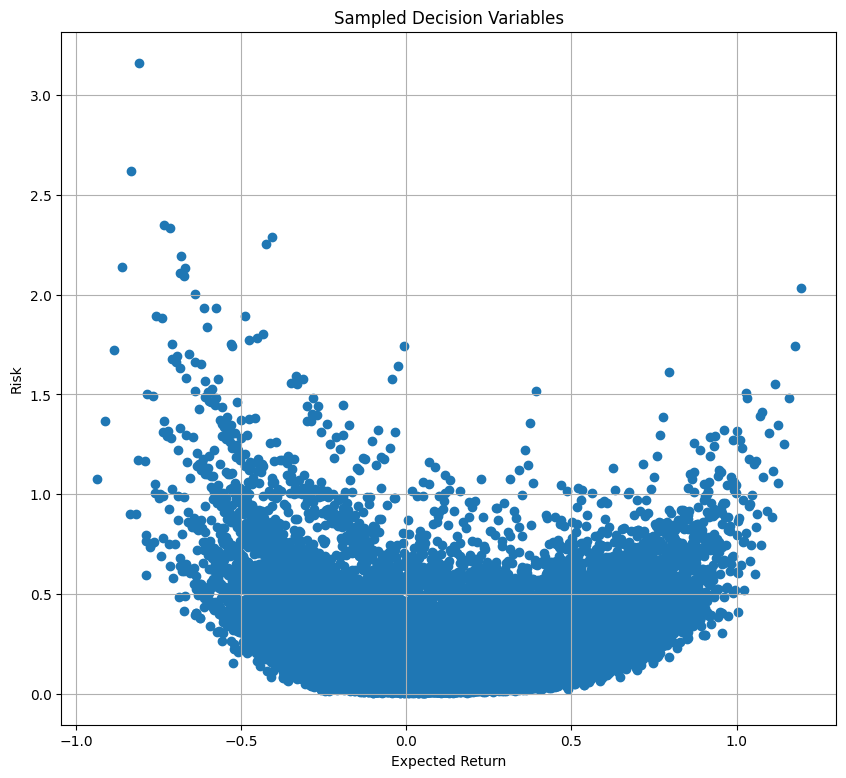

In [9]:
solver.plot_sampled_decision_variables(20, 0.2)

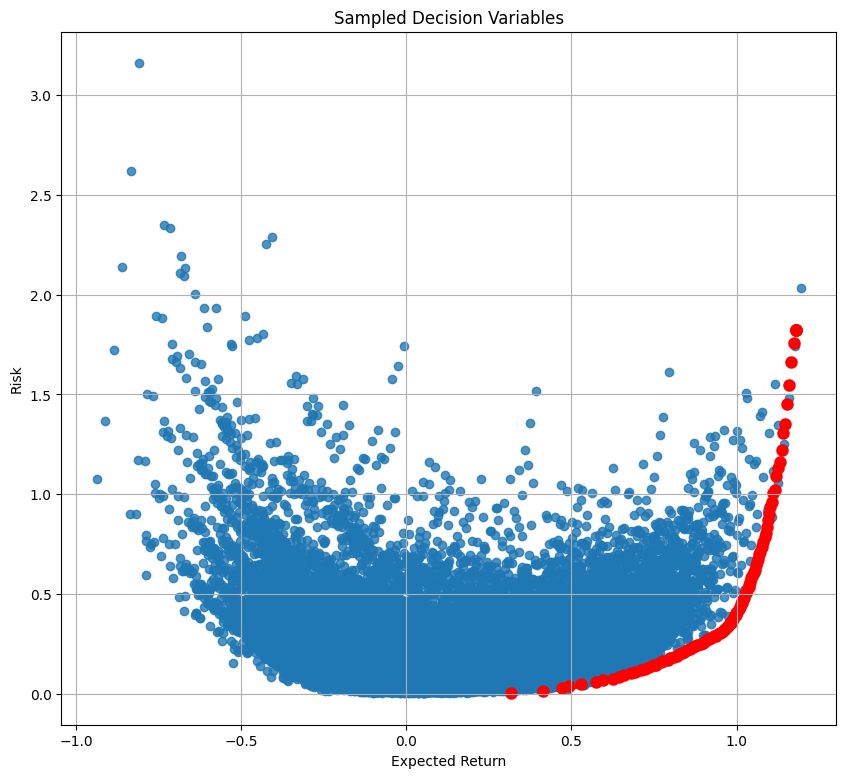

In [10]:
solver.plot_front(solutions, n=20, step=0.2)

In [11]:
ref_point = np.array([1.1, 1.1], dtype=np.float32)
population_values = GS.normalize_population_values(population, num_dims=2)
hv_value = calculate_2d_hyperarea(population_values, ref_point)
print("Hyperarea:", hv_value)

Hyperarea: 1.0705826331083357


In [12]:
GS = GeneticSolver(data, linear_predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population = GS.genetic_optimize(generations=100, neighborhood_size=5)
solutions = GS.get_solutions_from_population_3D(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


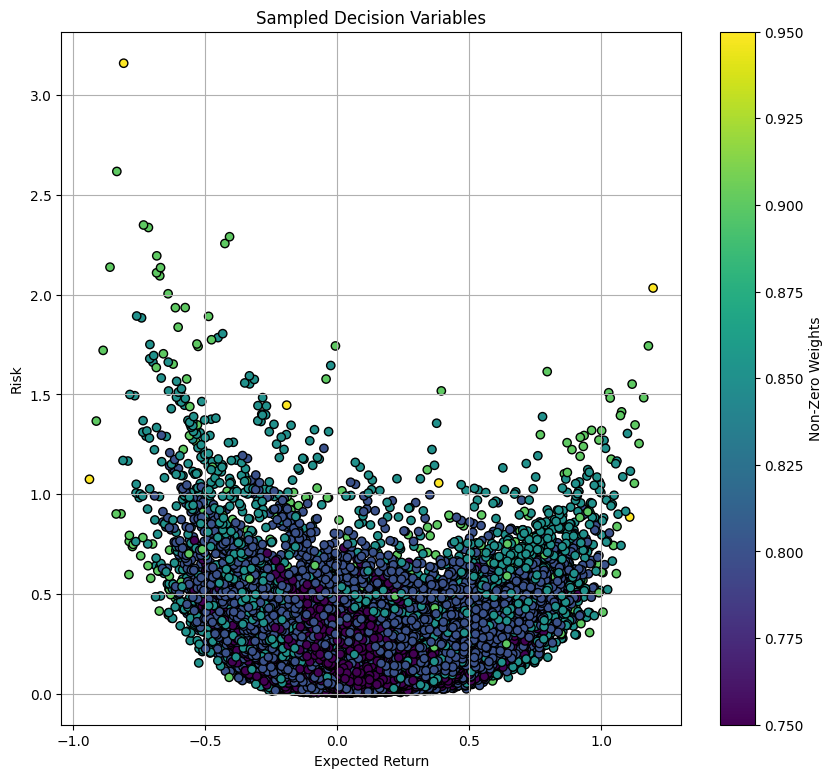

In [13]:
GS.plot_sampled_3D()

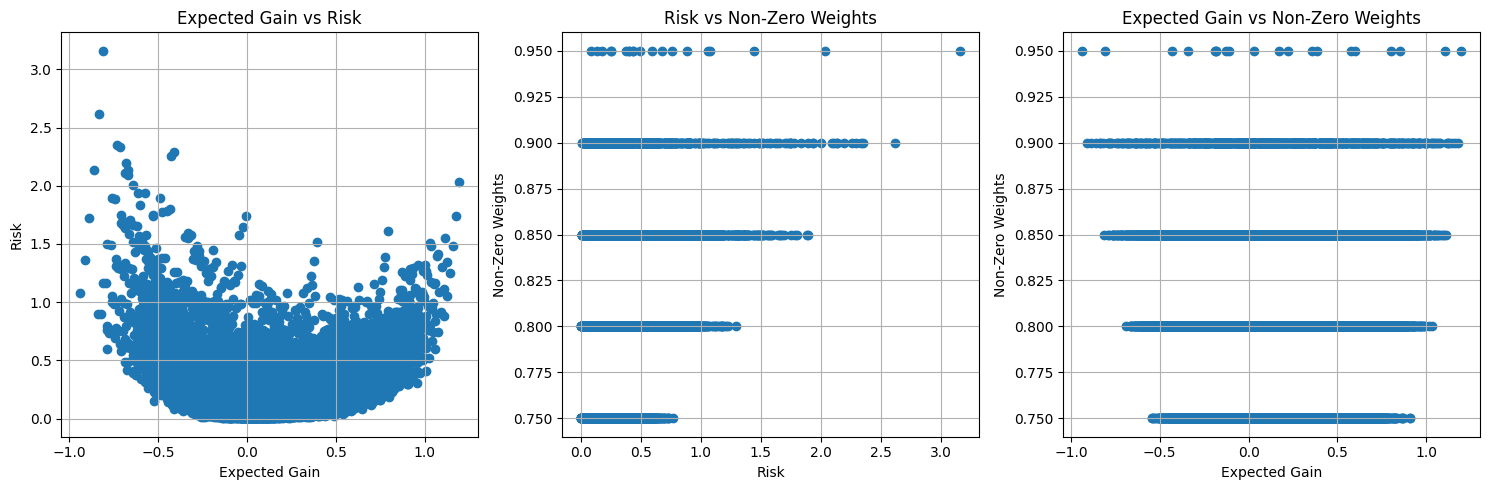

In [14]:
GS.plot_sampled_3D(color=False)

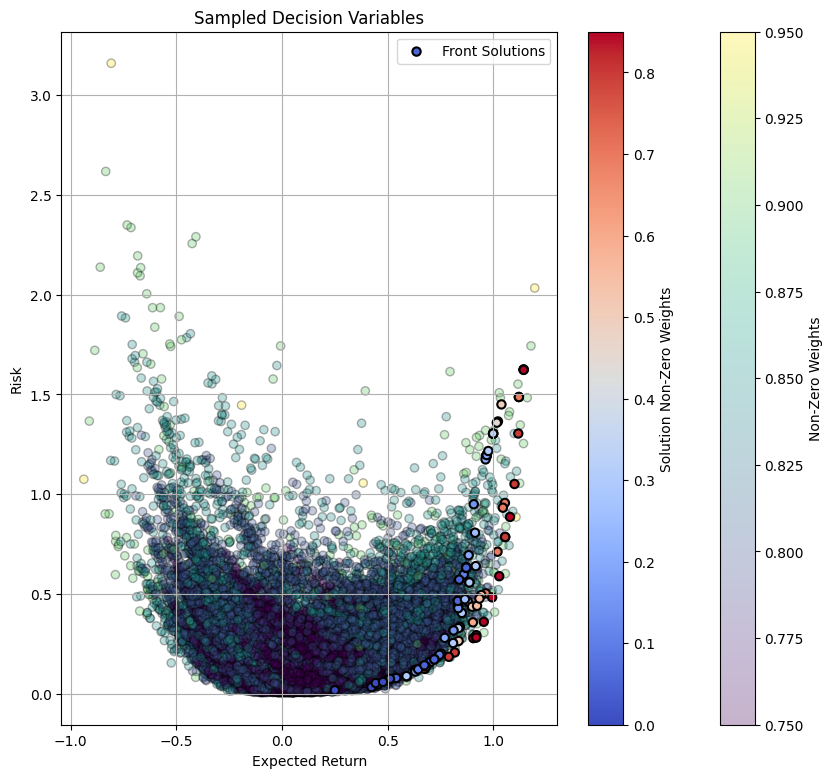

In [15]:
GS.plot_front_3D(solutions)

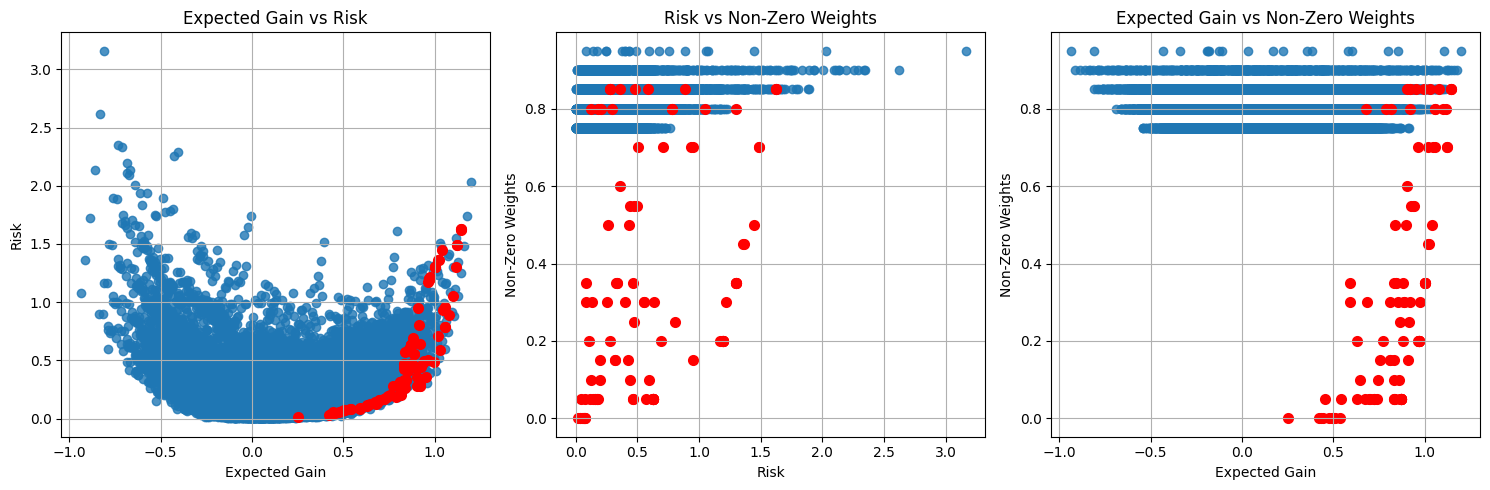

In [16]:
GS.plot_front_3D(solutions, color=False)

In [17]:
ref_point = np.array([1.1, 1.1, 1.1], dtype=np.float32)
population_values = GS.normalize_population_values(population, num_dims=3)
hv_value = calculate_3d_hypervolume(population_values, ref_point)
print("Hypervolume:", hv_value)

Hypervolume: 1.033485


d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:98: RuntimeWarning: overflow encountered in cast
  q.cargo[dimIndex] > bounds[dimIndex] or q.prev[dimIndex].cargo[dimIndex] >= bounds[dimIndex]):
d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:244: RuntimeWarning: overflow encountered in cast
  if bounds[i] > node.cargo[i]:
d:\MOO\MOO_env\lib\site-packages\pymoo\vendor\hv.py:258: RuntimeWarning: overflow encountered in cast
  if bounds[i] > node.cargo[i]:


In [ ]:
GER = GeneticExperimentRunner()
GER.get_hypervolume_vs_population_size_vs_generations([10, 20, 50, 100], [10, 20, 50, 100], data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

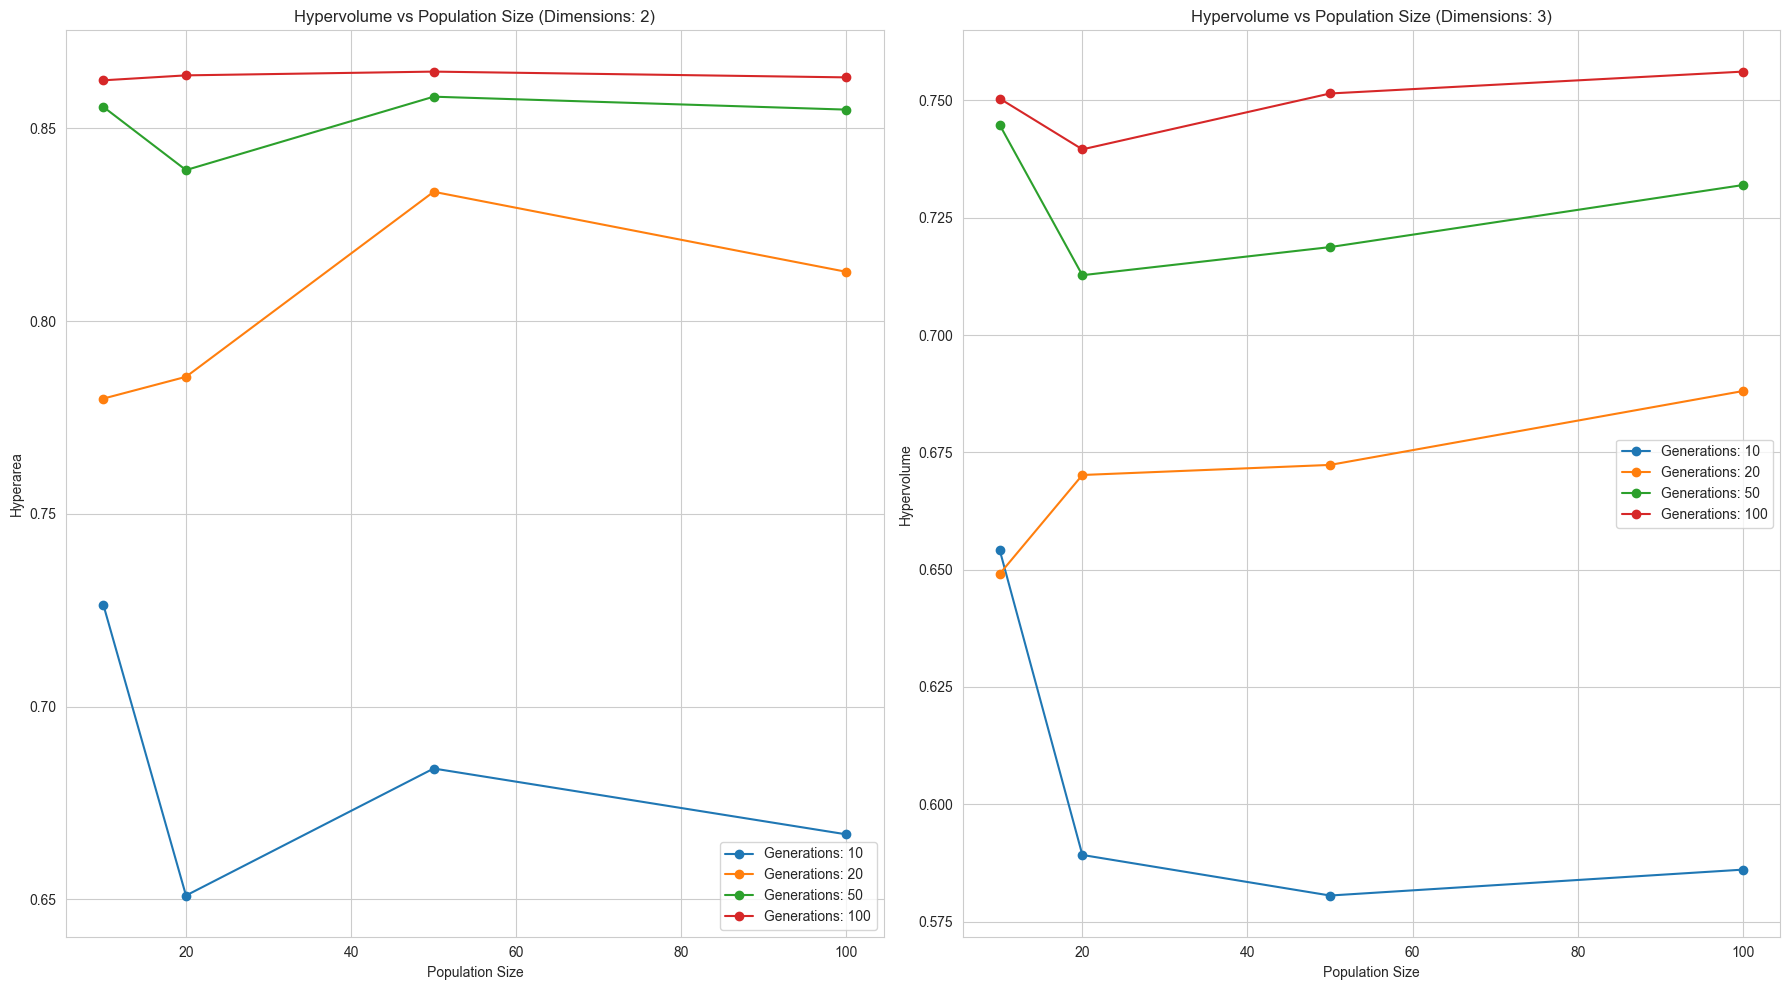

In [ ]:
GER.plot_hypervolume_vs_population_size_vs_generations()

In [ ]:
GER.get_convergence(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

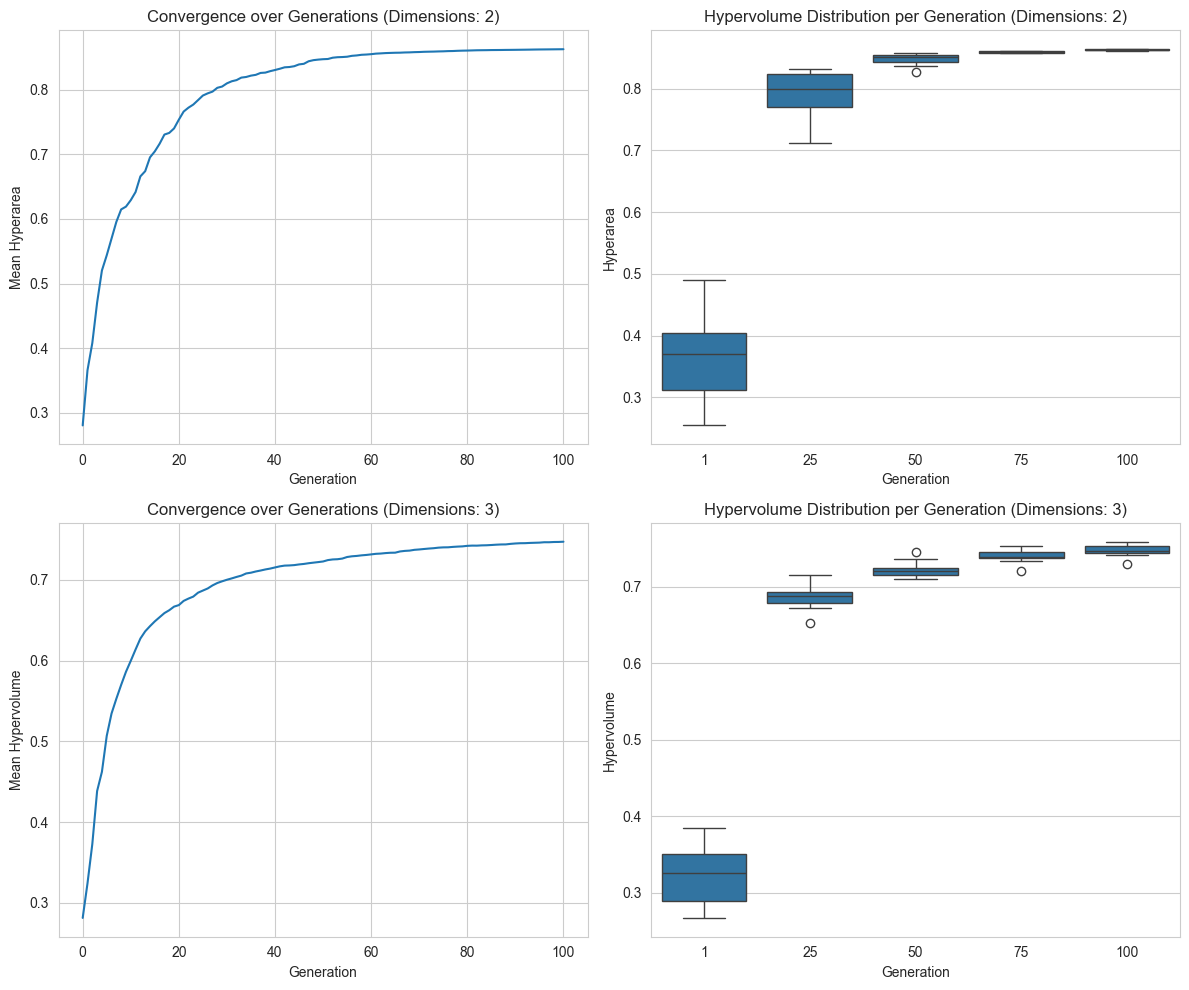

In [ ]:
GER.plot_convergence()

In [ ]:
GER.get_genetic_vs_classic(data, linear_predictions, risks, num_retries=10)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e

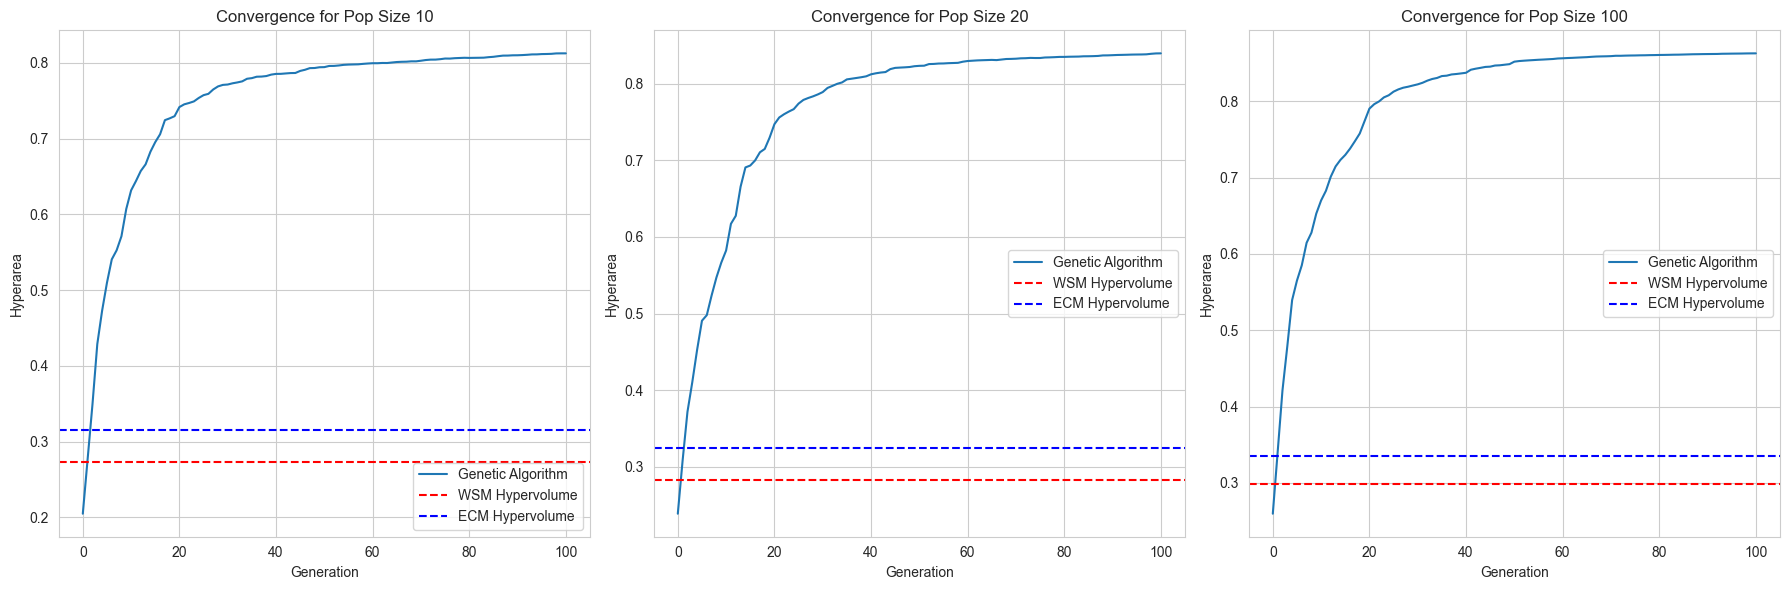

In [ ]:
GER.plot_genetic_vs_classic()